In [ ]:
import os
import json
import torch
import pandas as pd
import logging
import importlib
from pathlib import Path
import numpy as np
import random

import sys
PROJECT_DIR = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER"
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import multiomic_transformer.utils.data_formatter as data_formatter
import multiomic_transformer.utils.experiment_handler as experiment_handler

random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

# Training Data Preparation and Caching

The model uses cached per-chromosome data to help speed up training. Here, we will go through the process of building the necessary tensors and reference files to train the gene prediction model.

## Set up the TrainingDataFormatter

The training data formatter ensures that the correct data files and output directories exist and helps to keep everything standardized.

In [2]:
importlib.reload(data_formatter)

<module 'multiomic_transformer.utils.data_formatter' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/src/multiomic_transformer/utils/data_formatter.py'>

In [3]:
# Path to the project directory (same as Git repository root)
project_dir = Path(PROJECT_DIR)

# Path to the training output directory. Used to store the preprocessing config
output_dir = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/experiments")

# Name of the dataset / experiment to run
experiment_name = "Macrophage_buffer_1_raw_muon_preprocessing_new_cache"

# Organism code for the dataset. Supports either "mm10" or "hg38"
organism_code = "hg38"

# List of samples in the training datset. 
# Each of these should have its own subdirectory in the processed data directory
sample_names = ["buffer_1"]

# List of chromosomes. Used to split the data by chromsome for caching and training.
# Should be in the format "chr1", "chr2", etc. and should match the chromosome names in the processed data files.
chrom_list = [f"chr{i}" for i in range(1, 21)]

tdf = data_formatter.TrainingDataFormatter(
    project_dir=project_dir,
    experiment_name=experiment_name,
    organism_code=organism_code,
    sample_names=sample_names,
    chrom_list=chrom_list,
    output_dir=output_dir / experiment_name,
)

with open(tdf.output_dir / "file_paths.json", "r") as f:
    file_paths = json.load(f)

  - Found existing genome file: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/reference_genome/hg38/hg38.fa.gz
  - hg38.fa.gz is already BGZF; skipping transcode
  - Index already exists: hg38.fa.gz.fai, hg38.fa.gz.gzi
Genome ready: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/reference_genome/hg38/hg38.fa.gz
Found existing gene_info: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/hg38
Found existing GTF: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/hg38/Homo_sapiens.GRCh38.113.gtf.gz
Map sizes: {'n_official': 193850, 'n_ens2sym': 46575, 'n_entrez2sym': 193717, 'n_alias2sym': 69419}
Loaded existing settings from /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/Macrophage_buffer_1_raw_muon_preprocessing_new_cache/settings.json


## Sample-Level Data Preparation

We first load the pseudobulk data from the Muon QC and preprocssing pipeline. The data files are loaded and the peak and gene names are standardized.

We load the pseudobulk data for the sample, which also creates a list of gene names. The `split_genes_into_tfs_and_tgs` function checks which of the genes in the gene name list overlap with an organism-specific [file of TF names from CIS-BP](https://mitra.stanford.edu/kundaje/marinovg/oak/various/motifs/CIS-BP/TF_Information_all_motifs.txt) to create `tfs` and `tgs` attributes.


In [ ]:
sample_name = sample_names[0]

tg_pseudobulk_path = tdf.file_paths["processed"]["base_dir"] / sample_name / "TG_pseudobulk.parquet"
logging.info(f"TG pseudobulk path: {tg_pseudobulk_path}")
base_pseudobulk_rna_df = pd.read_parquet(tg_pseudobulk_path)


logging.info(f"Base Num Genes: {base_pseudobulk_rna_df.shape[0]}")
logging.info(f"Base Num Metacells: {base_pseudobulk_rna_df.shape[1]}")

TG pseudobulk path: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/Macrophage_buffer_1_raw_muon_preprocessing_new_cache/buffer_1/TG_pseudobulk.parquet
Base Num Genes: 14563
Base Num Metacells: 792


In [ ]:
sample_name = sample_names[0]

pseudobulk_rna_df = tdf.load_pseudobulk_rna_df(sample_name)

logging.info(f"Number of genes: {len(tdf.genes):,}")

# Next the genes are classified as TFs or TGs by checking which genes in the data are in the reference TF list. 
tdf.tfs, tdf.tgs = tdf.split_genes_into_tfs_and_tgs(tdf.genes)
logging.info(f"  - TFs: {len(tdf.tfs):,} (First 3: {tdf.tfs[:3]})")
logging.info(f"  - TGs: {len(tdf.tgs):,} (First 3: {tdf.tgs[:3]})")

Number of genes: 14,563
  - TFs: 1,180 (First 3: ['AC092835', 'ADNP', 'ADNP2'])
  - TGs: 13,376 (First 3: ['A1BG', 'A2M', 'A2ML1'])


The pseudobulk ATAC data is loaded, which also creates a list of peak names

In [ ]:
pseudobulk_atac_df = tdf.load_pseudobulk_atac_df(sample_name)

logging.info(f"Number of peaks: {len(tdf.peaks):,} (First 3: {tdf.peaks[:3]})")

Number of peaks: 121,984 (First 3: ['chr1:180546-181326', 'chr1:191323-192133', 'chr1:267079-267655'])


A BED file of the peak locations is created using `create_peak_bed_file` and the peak locations are stored as a dataframe in `tdf.peak_locs_df`.

In [7]:
tdf.create_peak_bed_file(pseudobulk_atac_df, sample_name)
display(tdf.peak_locs_df.head())

,chrom,start,end,strand,peak_id
0,chr1,180546,181326,.,chr1:180546-181326
1,chr1,191323,192133,.,chr1:191323-192133
2,chr1,267079,267655,.,chr1:267079-267655
3,chr1,267759,268290,.,chr1:267759-268290
4,chr1,270895,271779,.,chr1:270895-271779


### Calculate peak to gene distance

Next, we will use the peak bed file created when loading the peak pseudobulk dataset to calculate the distance between each peak and each gene within 1 Mb. This will create a bias tensor to help the model prioritize genes that are closer to peaks when training the peak-TG cross-attention portion of the model.

In [8]:
tdf.create_peak_to_tg_distance_file(
    sample_name=sample_name,
    force_recalculate=False,
    filter_to_nearest_gene=False,
)

  - Loading saved peak to TSS distance file


,peak_chr,peak_start,peak_end,peak_id,gene_chr,gene_start,gene_end,target_id,TSS_dist,TSS_dist_score
462657,chr19,18385677,18386562,chr19:18385677-18386562,chr19,18386562,18386563,MIR3189,0,1.000000
510025,chr22,20298984,20299760,chr22:20298984-20299760,chr22,20299760,20299761,PRODHLP,0,1.000000
116917,chr3,179649316,179650199,chr3:179649316-179650199,chr3,179650200,179650201,H3P13,1,0.999950
67487,chr2,74548651,74549458,chr2:74548651-74549458,chr2,74549459,74549460,LOXL3,1,0.999950
141596,chr5,59034128,59035026,chr5:59034128-59035026,chr5,59035027,59035028,PDE4D-AS1,1,0.999950
...,...,...,...,...,...,...,...,...,...,...
270555,chr10,132684039,132684794,chr10:132684039-132684794,chr10,132784765,132784766,NKX6-2,99971,0.006748
25224,chr1,108063441,108064341,chr1:108063441-108064341,chr1,107964367,107964368,VAV3-AS1,99974,0.006747
443902,chr18,55328041,55328931,chr18:55328041-55328931,chr18,55228955,55228956,TCF4,99976,0.006746
182363,chr6,109877341,109878271,chr6:109877341-109878271,chr6,109978256,109978257,GPR6,99985,0.006743


## Chromosome-Specific Data Formatting


In [9]:
total_TG_pseudobulk_global, pseudobulk_chrom_dict = tdf.aggregate_pseudobulk_datasets(force_recalculate=False)
total_TG_pseudobulk_global.head()

  - Found existing global and per-chrom pseudobulk; loading...


,AAACAGCCATAGGCGA-1,AAACCAACAATCCTAG-1,AAACCGCGTGCTCACC-1,AAAGCACCATAATGTC-1,AAAGCACCATTAAGTC-1,AAAGCCCGTGGAAACG-1,AAATCCGGTTGCACAA-1,AAATGCCTCGAGGAAC-1,AAATGGCCACAAACTT-1,AACAAGCCAGTCTAGC-1,...,TTTATGGAGCTTGCTC-1,TTTATGGAGGATGATG-1,TTTCACCCATGATTGT-1,TTTCAGTTCCCTGTTA-1,TTTCCACCACCATATG-1,TTTCCGGGTAGTTAAC-1,TTTCCGGGTTGCAGTA-1,TTTCTCACAGGCTTCG-1,TTTGACCGTGAAACAA-1,TTTGGTGCAGAATGAC-1
A1BG,0.145938,0.375733,0.031888,0.075666,0.019815,0.267360,0.081609,-0.068398,0.136295,0.174090,...,0.093855,-0.062284,-0.071432,-0.176623,0.142207,-0.055086,0.161324,0.077176,0.053658,-0.062983
A2M,0.027574,-0.130627,-0.063552,0.030216,0.100016,0.071931,0.341915,-0.120708,0.139898,-0.101431,...,-0.134470,0.426040,-0.233120,-0.300487,0.268734,0.191113,-0.396636,0.318500,0.335033,0.329044
A2ML1,0.151865,0.097345,-0.099689,0.902793,0.411699,-0.059665,-0.086548,-0.087312,-0.064451,-0.098521,...,-0.057896,-0.099689,-0.044337,-0.030960,-0.057973,0.029453,-0.099689,-0.083345,-0.097404,-0.062819
A3GALT2,-0.155416,-0.089188,-0.080371,0.077545,0.357054,-0.121030,-0.021690,-0.144277,-0.134403,0.045692,...,-0.124641,-0.132327,-0.123117,0.344077,0.089098,0.070931,-0.164678,0.054090,0.062294,-0.044594
A4GALT,-0.121337,0.134273,-0.012551,-0.128767,-0.128767,0.049067,-0.055950,-0.093198,-0.089228,0.252164,...,-0.111661,-0.128767,0.029071,-0.116722,-0.114493,-0.127252,-0.066699,-0.120236,-0.112274,-0.073179


In [10]:
tdf.create_chrom_files(total_TG_pseudobulk_global, pseudobulk_chrom_dict, force_recalculate=False, verbose=False)

  - All required global files exist. Skipping preprocessing.
  - Number of chromosomes: 20: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20']
  - Processing chromosomes for dataset: Macrophage_buffer_1_raw_muon_preprocessing_new_cache
  - All required output files exist for chr1. Skipping preprocessing.
  - All required output files exist for chr2. Skipping preprocessing.
  - All required output files exist for chr3. Skipping preprocessing.
  - All required output files exist for chr4. Skipping preprocessing.
  - All required output files exist for chr5. Skipping preprocessing.
  - All required output files exist for chr6. Skipping preprocessing.
  - All required output files exist for chr7. Skipping preprocessing.
  - All required output files exist for chr8. Skipping preprocessing.
  - All required output files exist for chr9. Skipping preprocessing.
  - All requi

We can check that all of the required cached files exist for the experiment.

In [11]:
num_missing_files, missing_file_dict = tdf.check_cached_file_exist()
logging.info(f"Missing {num_missing_files} cached files")
missing_file_dict

All required files are present.


Missing 0 cached files


{'sample': [], 'chromosome': {}}

# Testing how the data prep and caching interacts with the experiment_loader class

In [ ]:
def load_ground_truth(ground_truth_file):
    if type(ground_truth_file) == str:
        ground_truth_file = Path(ground_truth_file)
        
    if ground_truth_file.suffix == ".csv":
        sep = ","
    elif ground_truth_file.suffix == ".tsv":
        sep="\t"
        
    ground_truth_df = pd.read_csv(ground_truth_file, sep=sep, on_bad_lines="skip", engine="python")
    
    if "chip" in ground_truth_file.name and "atlas" in ground_truth_file.name:
        ground_truth_df = ground_truth_df[["source_id", "target_id"]]

    if ground_truth_df.columns[0] != "Source" or ground_truth_df.columns[1] != "Target":
        ground_truth_df = ground_truth_df.rename(columns={ground_truth_df.columns[0]: "Source", ground_truth_df.columns[1]: "Target"})
    ground_truth_df["Source"] = ground_truth_df["Source"].astype(str).str.upper()
    ground_truth_df["Target"] = ground_truth_df["Target"].astype(str).str.upper()
    
    # Build TF, TG, and edge sets for quick lookup later
    gt = ground_truth_df[["Source", "Target"]].dropna()

    gt_tfs = set(gt["Source"].unique())
    gt_tgs = set(gt["Target"].unique())
    
    gt_pairs = (gt["Source"] + "\t" + gt["Target"]).drop_duplicates()
    
    gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))
        
    return ground_truth_df, gt_lookup

logging.info("Loading ground truth datasets...")
GROUND_TRUTH_DIR = Path(PROJECT_DIR) / "data" / "ground_truth_files"
# gt_by_dataset_dict = {
#     "ChIP-Atlas mESC": load_ground_truth(GROUND_TRUTH_DIR / "chip_atlas_tf_peak_tg_dist.csv"),
#     "RN111": load_ground_truth(GROUND_TRUTH_DIR / "RN111.tsv"),
#     "RN112": load_ground_truth(GROUND_TRUTH_DIR / "RN112.tsv"),
#     "RN114": load_ground_truth(GROUND_TRUTH_DIR / "RN114.tsv"),
#     "RN116": load_ground_truth(GROUND_TRUTH_DIR / "RN116.tsv"),        
# }
gt_by_dataset_dict = {
    "ChIP-Atlas macrophage": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
}

Loading ground truth datasets...


In [ ]:
importlib.reload(experiment_handler)

# Verify that the data cache files exist. If not, this method will create them.
tdf.create_or_load_data_cache(sample_name=sample_names[0], force_recalculate=False)

# The ExperimentHandler is a higher level class that handles the training and evaluation of the model.
# It takes in a TrainingDataFormatter object to handle file paths, data loading, and caching.
logging.info("Initializing ExperimentHandler...")
exp = experiment_handler.ExperimentHandler(
    training_data_formatter=tdf,
    experiment_dir="/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/experiments/",
    model_num=2,
    silence_warnings=False,
)
# Loads a ground truth file with columns "Source" and "Target" for TF-TG interactions.
logging.info("Loading ground truth datasets...")
# GROUND_TRUTH_DIR = Path(PROJECT_DIR) / "data" / "ground_truth_files"
# gt_by_dataset_dict = {
#     "ChIP-Atlas macrophage": exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
# }

# Creates a MultiChromosomeDataset dataset class, which handles loading data for one chromosome
# at a time and caching it in memory. The max_cached argument controls how many chromosomes worth 
# of data can be cached in memory at once. Each batch only contains TG and window data from one chromosome.
# The chromosomes are loaded sequentially, starting with the first chromosome in the chrom_list.
logging.info("Creating dataset...")
exp.create_multichrom_dataset(max_cached=100)

# Prepares the Train/Val/Test dataloaders, being careful to balance the number of 
# batches from each chromosome in each set.
logging.info("Preparing DataLoader...")
train_loader, val_loader, test_loader = exp.prepare_dataloader(
    batch_size=32,
    num_workers=8
)

# Creates scalers for the RNA and ATAC data based on the training split.
logging.info("Creating scalers...")
exp.create_scalers(train_loader)

# Creates a new MultiomicTransformer model. Model attributes can be set to change
# the hyperparameters of the model.
logging.info("Creating model")
exp.create_new_model()

# exp.load_model()

# Runs model training and returns the trained model.
logging.info("Training model")
model = exp.train(
    train_loader=train_loader, 
    val_loader=val_loader, 
    num_epochs=500,
    max_batches=None,
    save_every_n_epochs=10,
    monitor_gpu_memory=True,
    profile_batches=True,
    allow_overwrite=True,
    silence_tqdm=True,
    )

# Runs gradient attribution to calculate the gradients between each TF input and each TG output.
logging.info("\nRunning Gradient Attribution")
exp.grn = exp.load_grn()
if exp.grn is None:
    exp.run_gradient_attribution(
        test_loader,
        max_batches=None,
        max_tgs_per_batch=None,
        )

# Calculates the AUROC of the predicted GRN against multiple ground truth datasets.
logging.info("\nCalculating AUROC")
auroc_df = exp.calculate_auroc_all_sample_gts(exp.grn, gt_by_dataset_dict)     
logging.info(f"Pooled Median AUROC: {auroc_df['pooled_median_auroc'].iloc[0]:.3f}")       
logging.info(f"Per-TF Median AUROC: {auroc_df['per_tf_median_auroc'].iloc[0]:.3f}")

All required files are present.
Skipping data cache creation.
Initializing ExperimentHandler...
Loading ground truth datasets...
Creating dataset...


Preparing DataLoader...
Creating scalers...
Creating model

Running Gradient Attribution

Calculating AUROC
Pooled Median AUROC: 0.518
Per-TF Median AUROC: 0.549


In [37]:
exp.calculate_auroc_all_methods(
    sample_names, 
    "Macrophage", 
    gt_by_dataset_dict, 
    grn=exp.grn
    )


Processing sample: buffer_1 | Dataset: Macrophage
  - Loading CellOracle
  - Loading SCENIC+
  - Loading Pando
  - Loading LINGER
  - Loading FigR
  - Loading TRIPOD
  - Loading GRaNIE

Evaluating pooled methods across samples
  - Evaluating CellOracle
  - Evaluating SCENIC+
  - Evaluating Pando
  - Evaluating LINGER
  - Evaluating FigR
  - Evaluating TRIPOD
  - Evaluating GRaNIE
  - Evaluating Gradient Attribution
method
SCENIC+                 0.579007
LINGER                  0.574302
CellOracle              0.563251
TRIPOD                  0.543921
GRaNIE                  0.531626
FigR                    0.519876
Gradient Attribution    0.518410
Pando                   0.491867
Name: auroc, dtype: float64

Per-TF evaluation of pooled methods across samples
  - Per-TF evaluating CellOracle
  - Per-TF evaluating SCENIC+
  - Per-TF evaluating Pando
  - Per-TF evaluating LINGER
  - Per-TF evaluating FigR
  - Per-TF evaluating TRIPOD
  - Per-TF evaluating GRaNIE
  - Per-TF evaluating Gr


--- Model Training Summary ---
Final R2 (unscaled): 0.4046
Final R2 (scaled): 0.4352
Average Epoch Time: 5.13 seconds

----- GRN Size -----
Number of unique TFs: 1,180
Number of unique TGs: 4,456
Number of edges: 5,258,080
tg_query_emb is in the model.

----- AUROC -----
Median Pooled AUROC: 0.518
Median Per-TF AUROC: 0.548
Macrophage_buffer_1_raw_muon_preprocessing_new_cache
Running forward pass to get predicted vs true TG expression for a subset of test batches...
Running forward pass: 100%|█████████████████████| 40/40 [00:01<00:00, 22.45it/s]


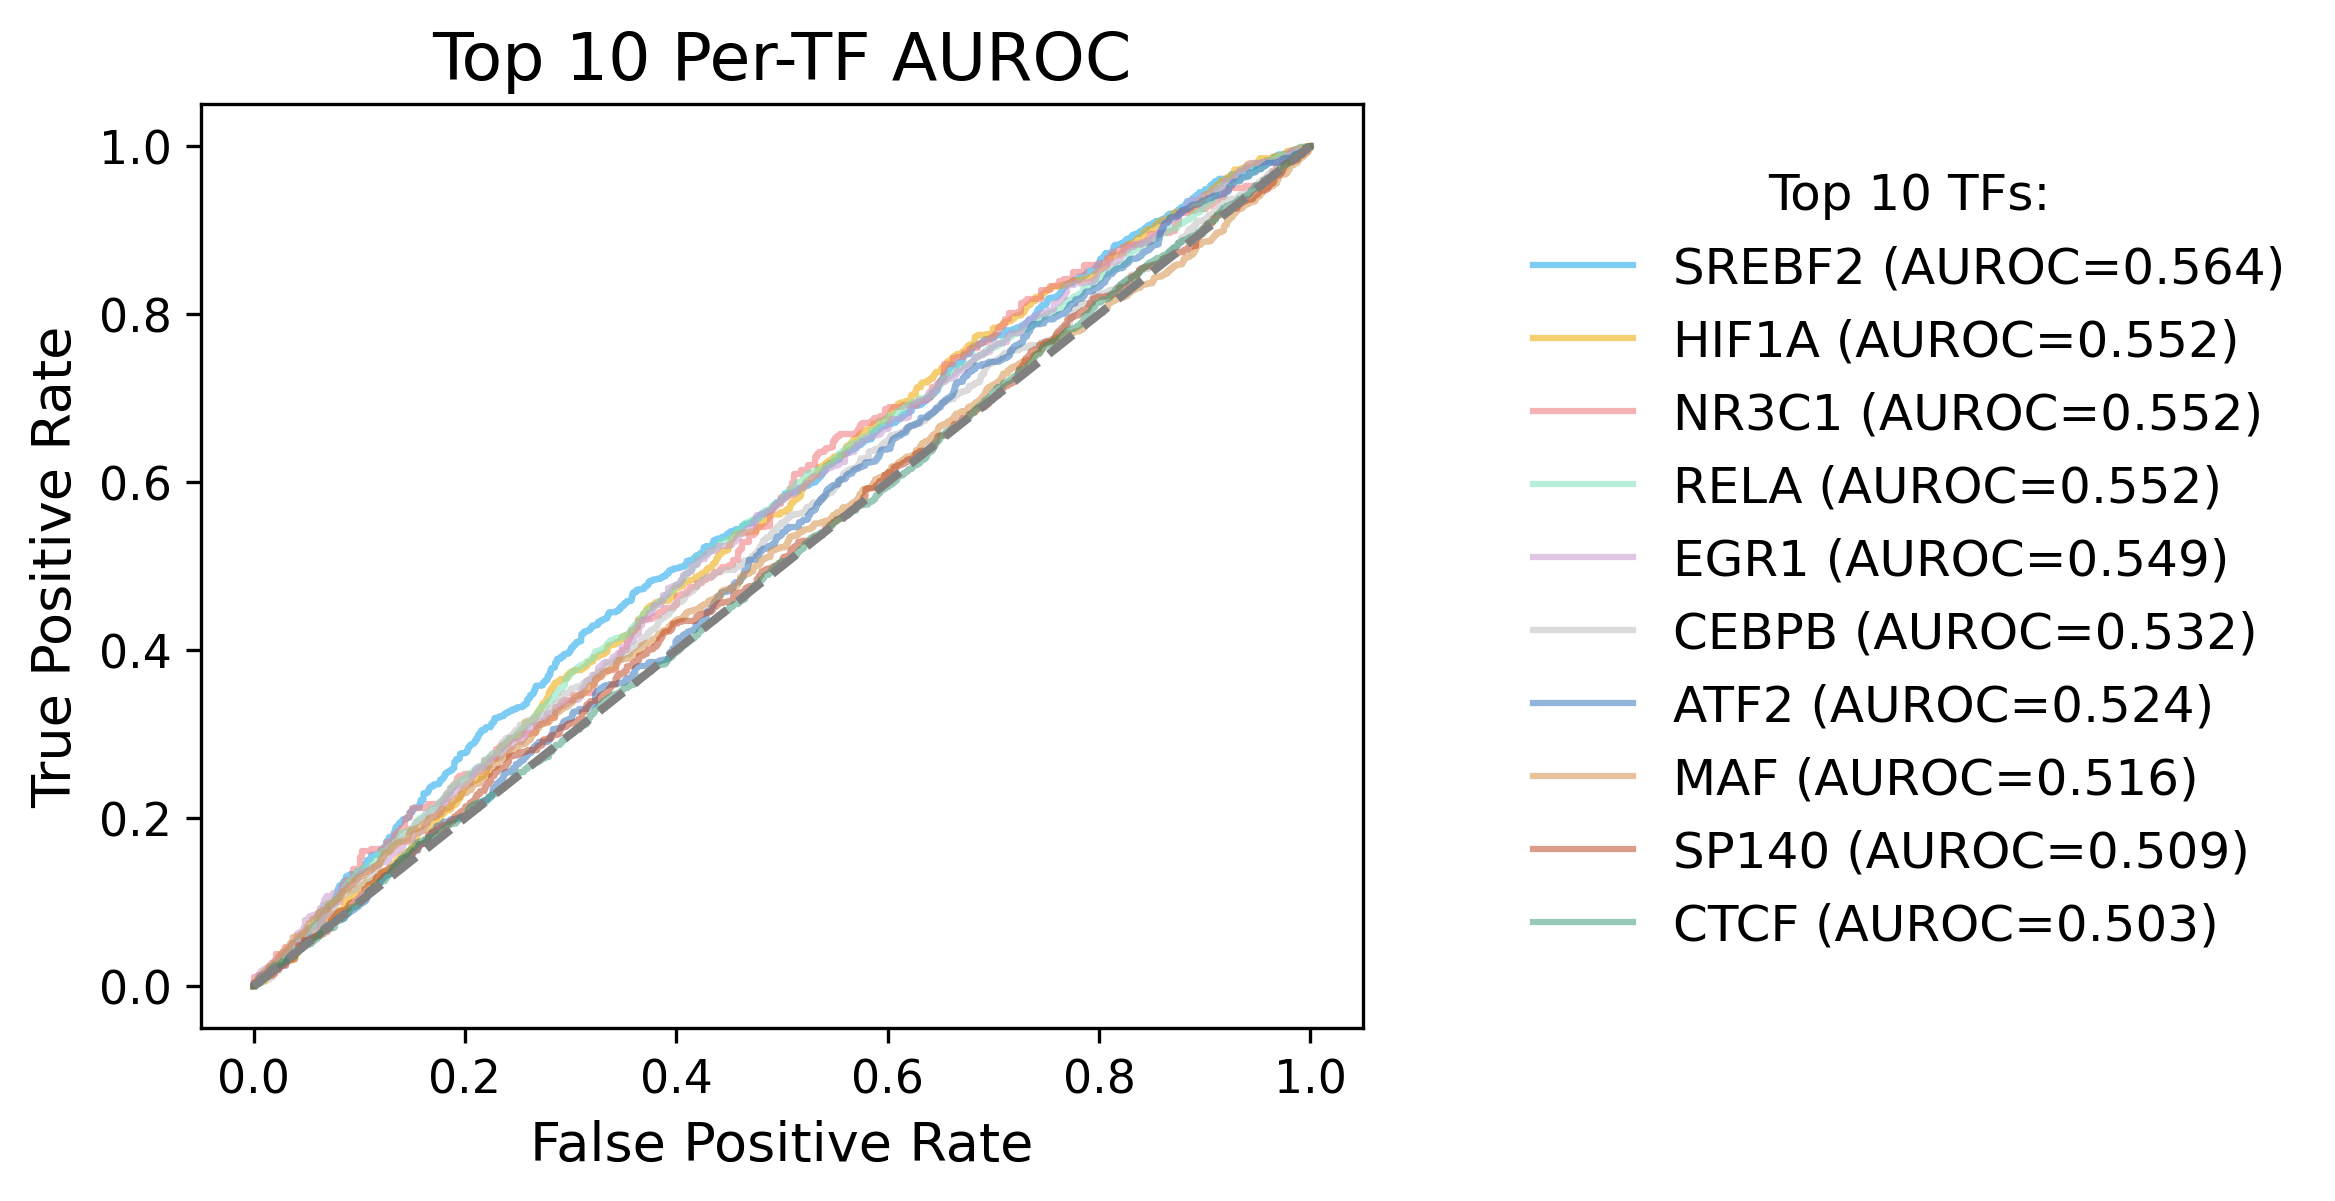

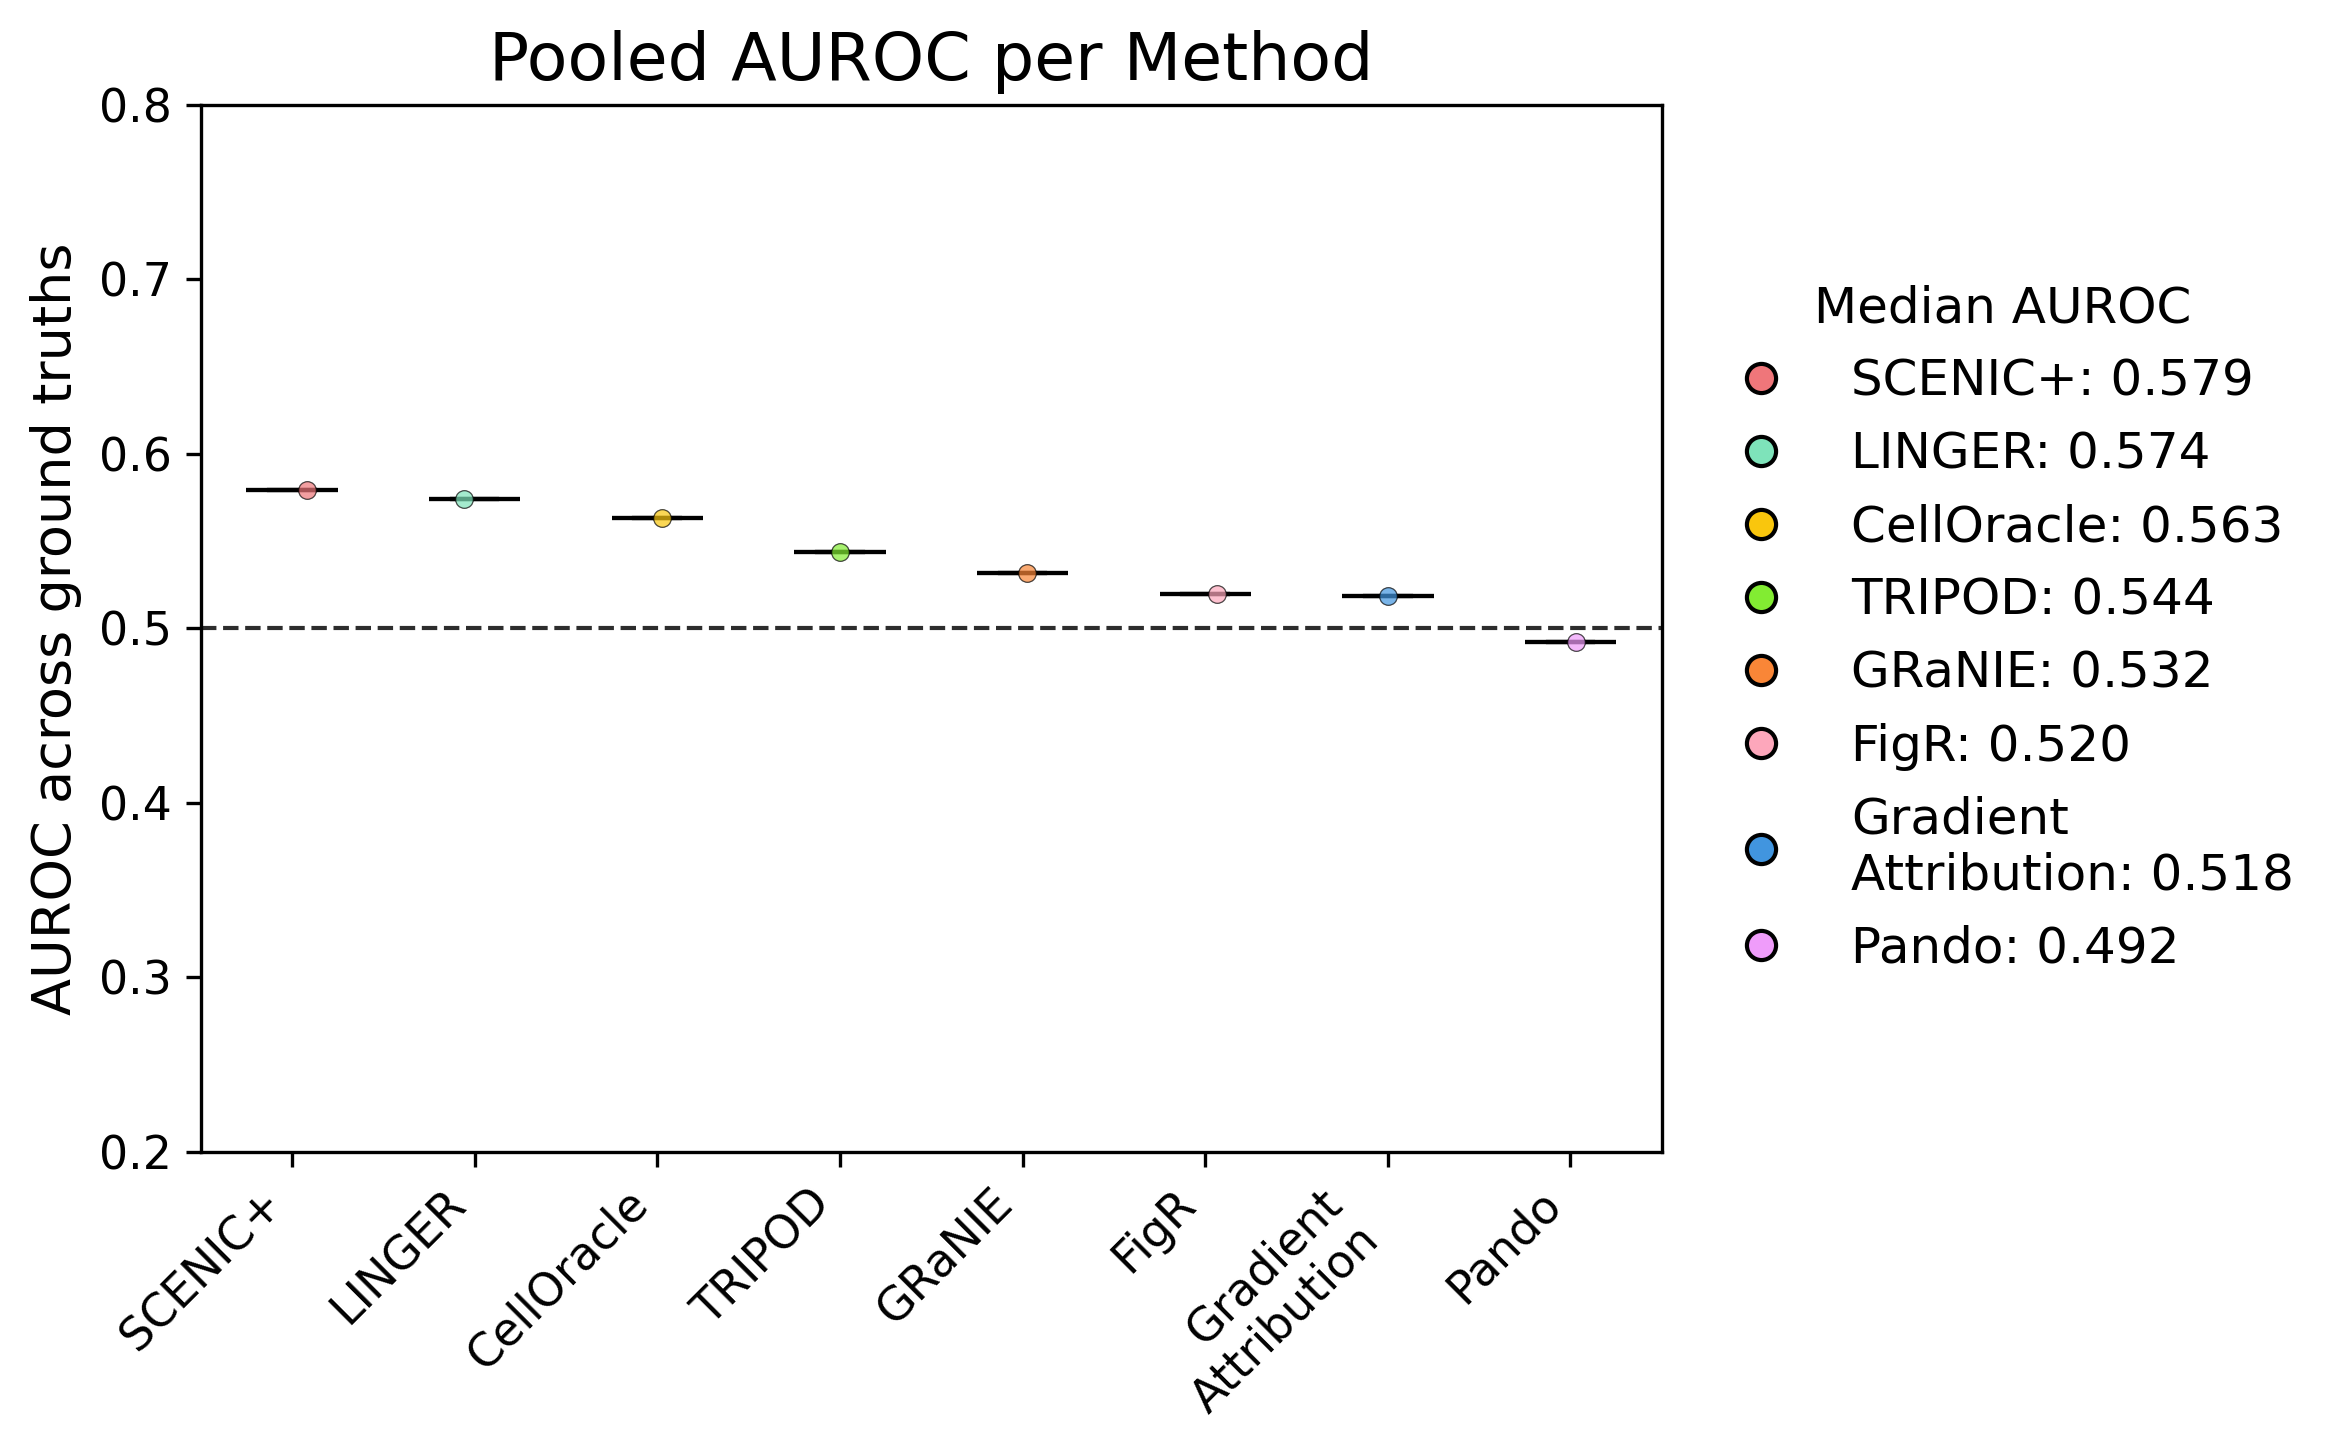

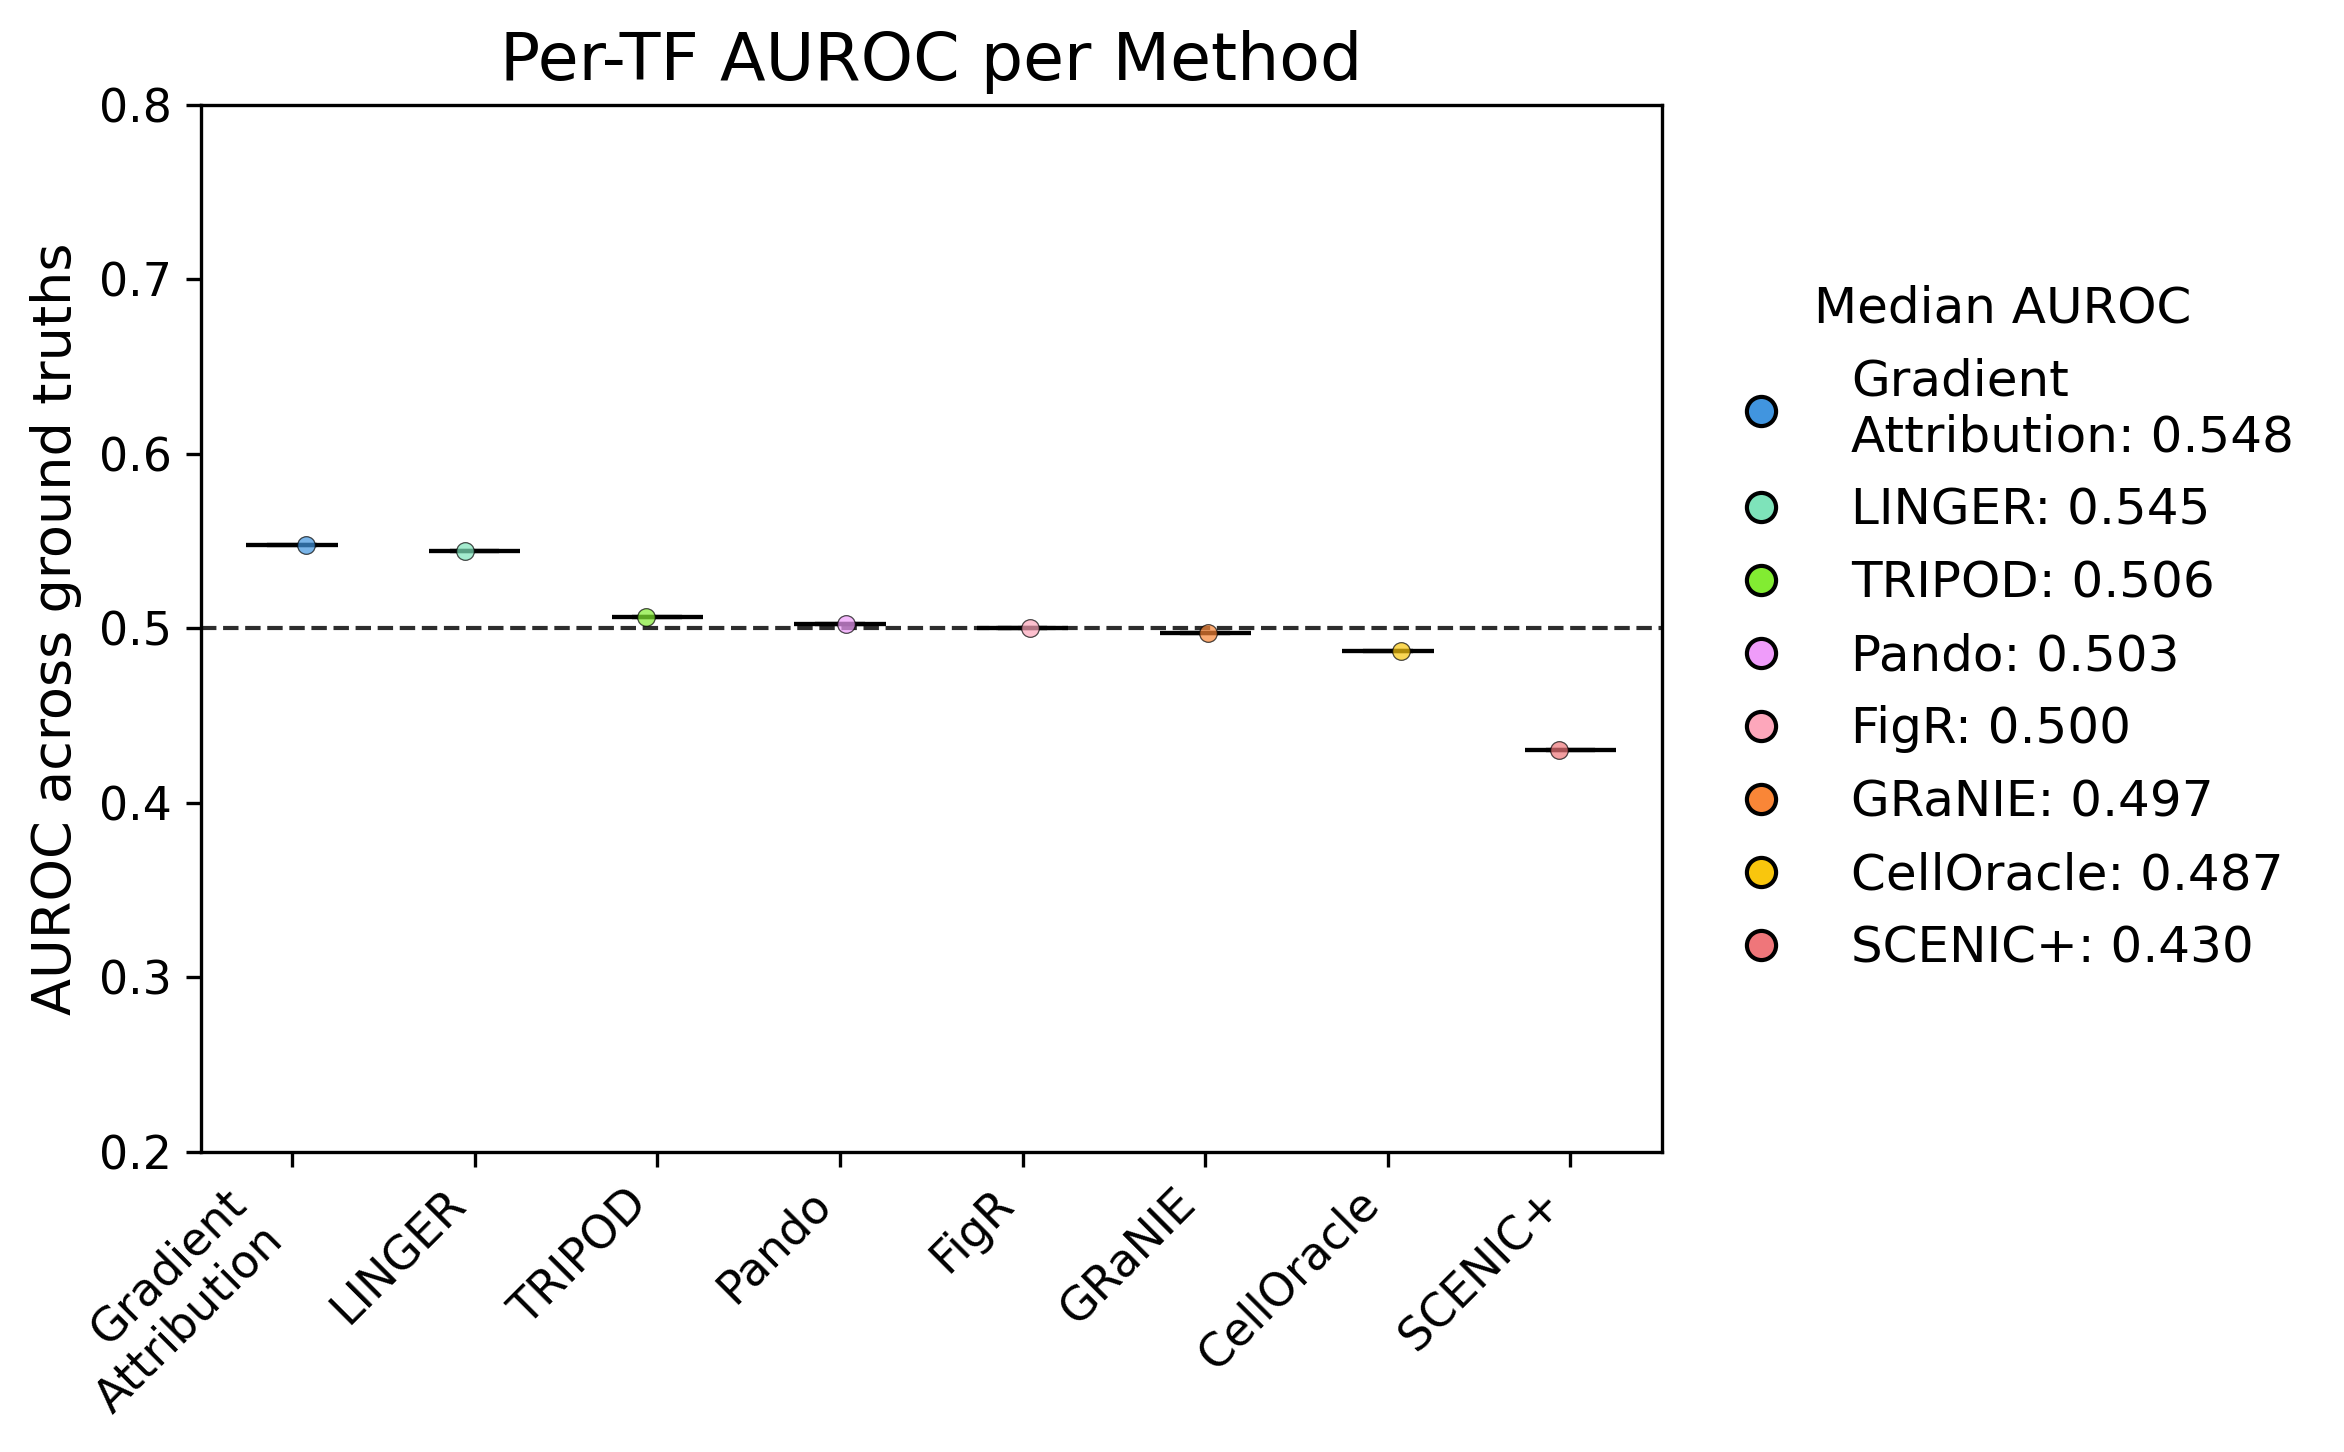

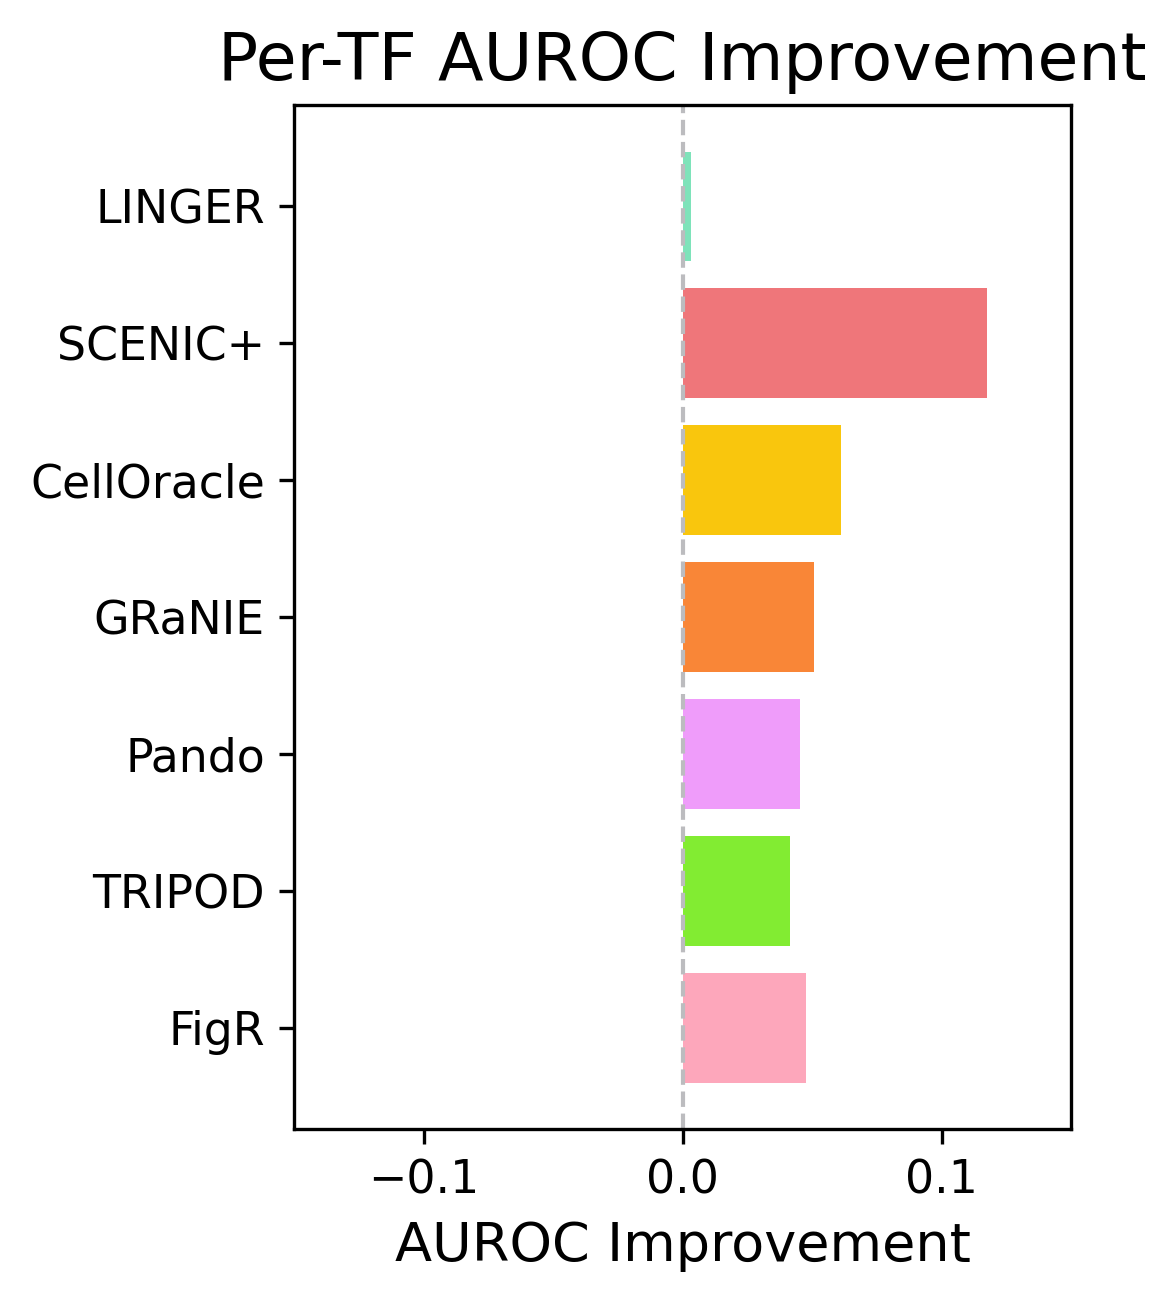

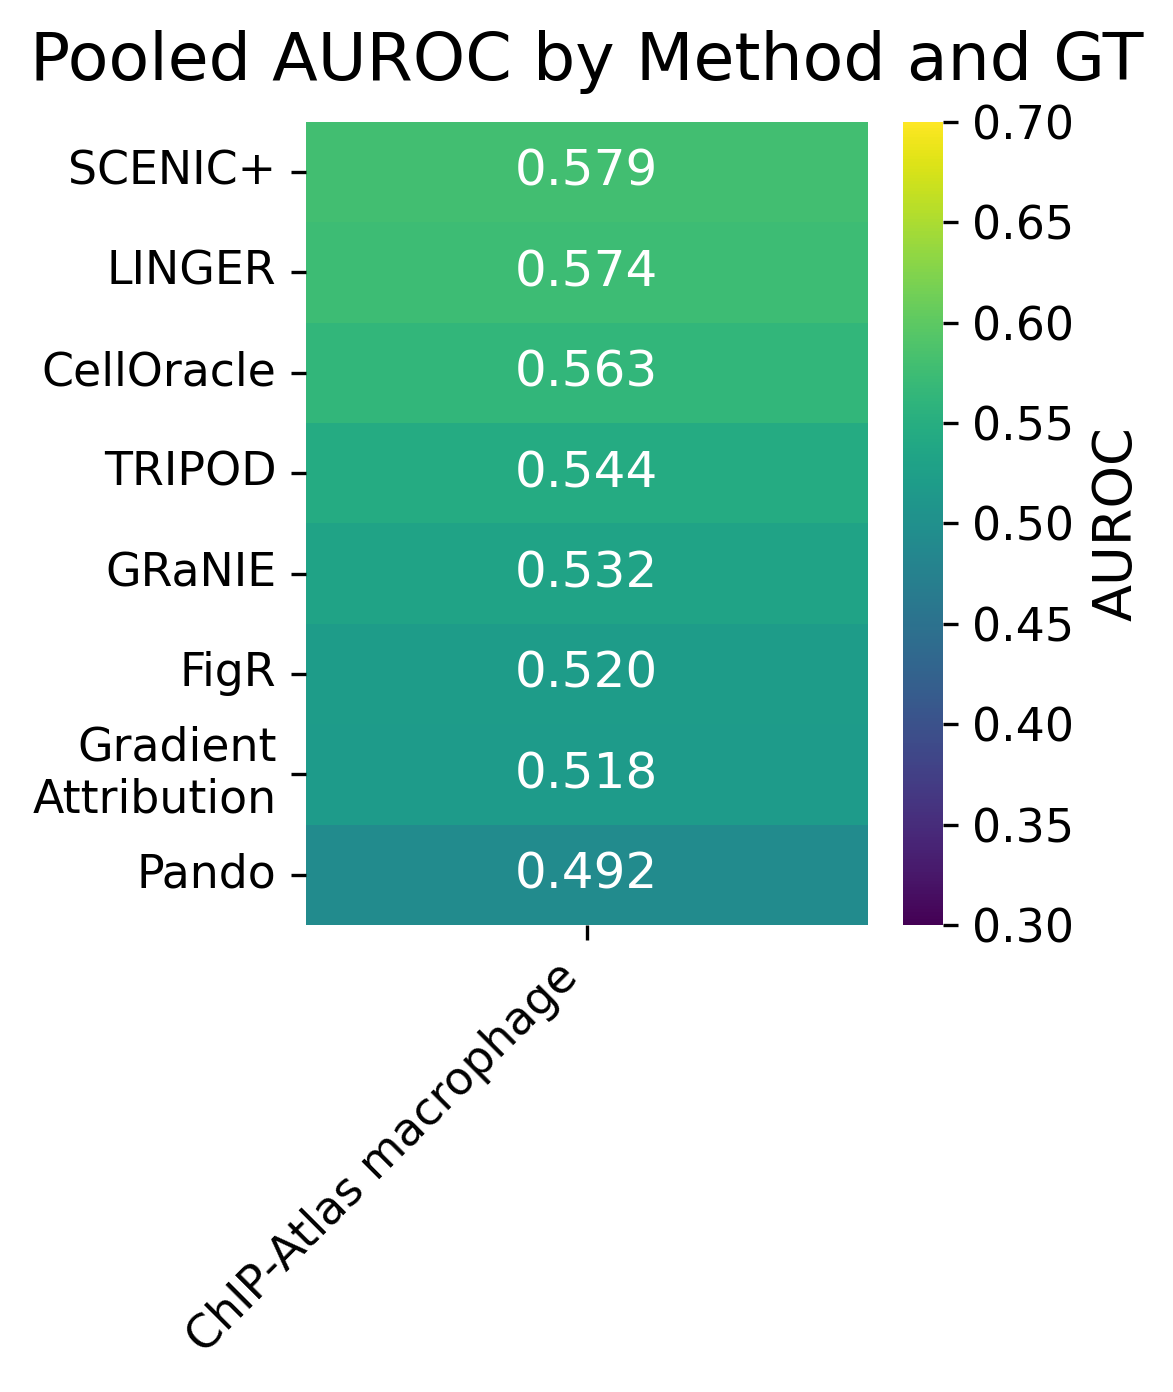

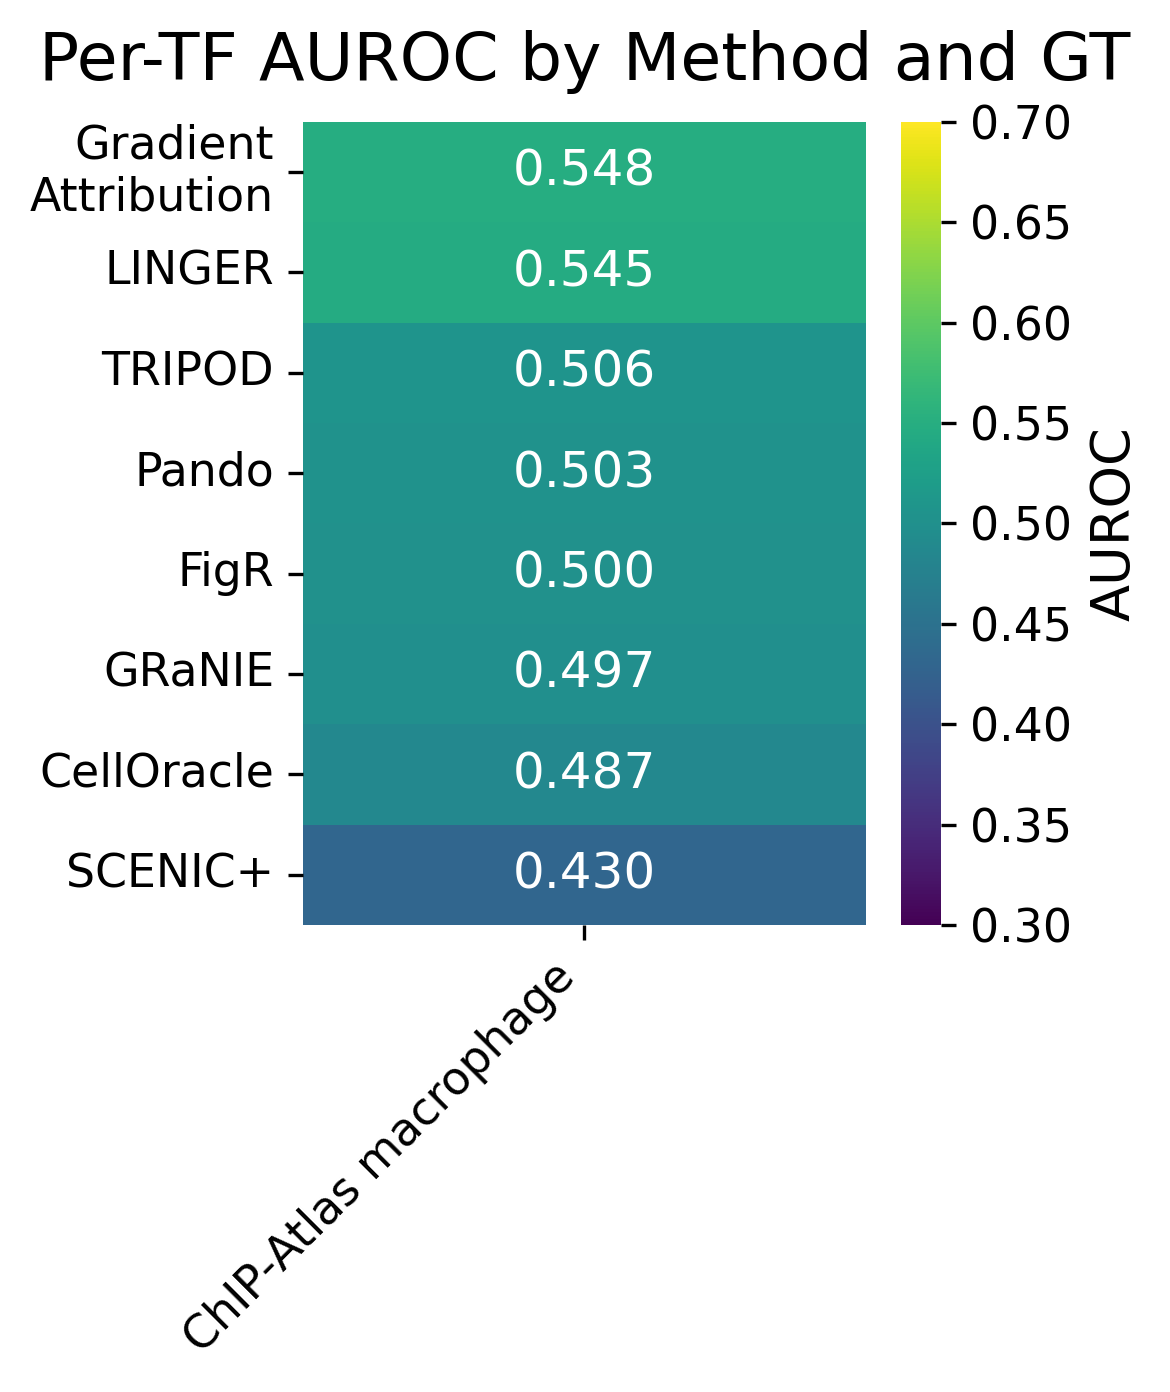

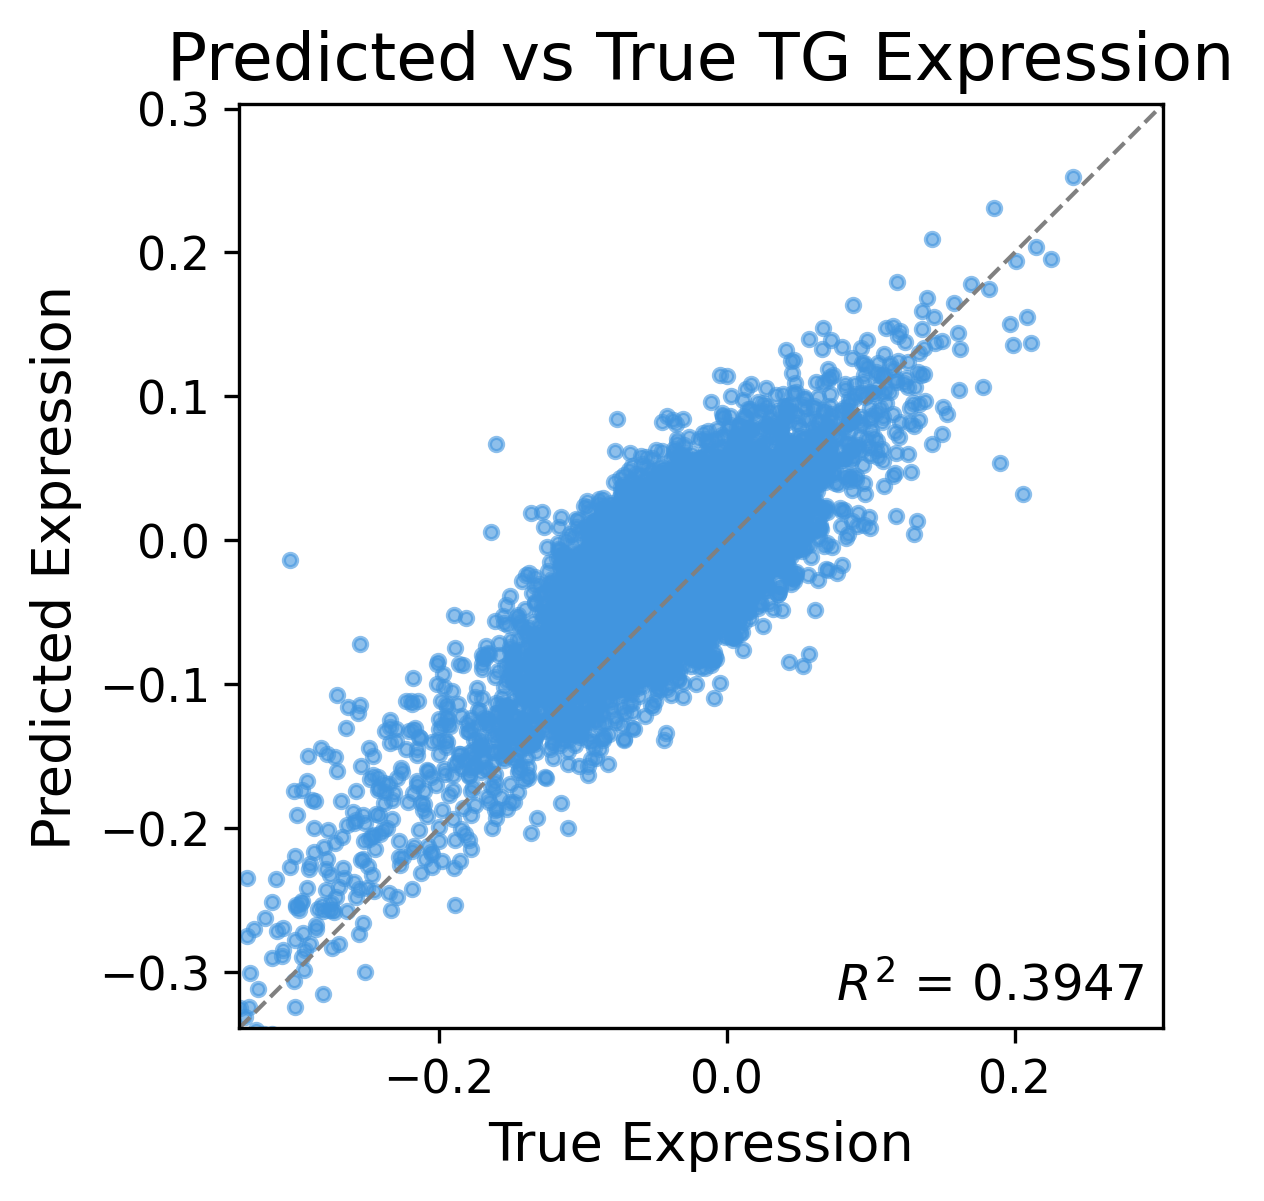

In [49]:
ground_truth_name = "ChIP-Atlas macrophage"

exp.epoch_log_df = pd.read_csv(exp.model_training_dir / "epoch_log.csv")
exp.epoch_log_df.iloc[-1]
final_r2u = exp.epoch_log_df.iloc[-1]["r2_unscaled"]
final_r2s = exp.epoch_log_df.iloc[-1]["r2_scaled"]
avg_epoch_time = exp.epoch_log_df["epoch_time_s"].mean()

logging.info(f"\n--- Model Training Summary ---")
logging.info(f"Final R2 (unscaled): {final_r2u:.4f}")
logging.info(f"Final R2 (scaled): {final_r2s:.4f}")
logging.info(f"Average Epoch Time: {avg_epoch_time:.2f} seconds")

num_edges = len(exp.grn)
num_tfs = exp.grn["Source"].nunique()
num_tgs = exp.grn["Target"].nunique()
# metacells = exp.model_training_params["metacells"]
# windows = exp.model_training_params["windows"]

logging.info(f"\n----- GRN Size -----")
logging.info(f"Number of unique TFs: {num_tfs:,}")
logging.info(f"Number of unique TGs: {num_tgs:,}")
logging.info(f"Number of edges: {num_edges:,}")
# logging.info(f"Number of Metacells: {metacells:,}")
# logging.info(f"Number of Windows: {windows:,}\n")

# Check if the "tg_identity_emb" is in the model
if hasattr(exp.model, "tg_query_emb"):
    logging.info("tg_query_emb is in the model.")
if hasattr(exp.model, "tg_identity_emb"):
    logging.info("tg_identity_emb is in the model.")

name = exp.experiment_name.replace("_", " ")
fig, per_tf_df, tf_curves = exp.plot_top_n_tf_roc_curves(
    exp.grn, 
    gt_by_dataset_dict[ground_truth_name], 
    ground_truth_name, 
    exp, 
    method_name="Gradient Attribution", 
    num_top_tfs_to_plot=10,
    min_edges=500,
    min_pos=50,
    balance=True,
    name_clean=name,
    override_title=f"Top 10 Per-TF AUROC"
    )
fig.show()

# fig = exp.plot_hist_roc_pr(
#     df,
#     gt_by_dataset_dict[sample_type],
#     method_name="Gradient Attribution",
#     y_log=False,
#     panel_kind="hist"
# )
# fig.show()

logging.info(f"\n----- AUROC -----")
per_tf_df_all =  pd.read_csv(exp.model_training_dir / "per_tf_auroc_auprc_results.csv")
pooled_df_all = pd.read_csv(exp.model_training_dir / "pooled_auroc_auprc_results.csv")

# gt_filter = ["ChIP-Atlas", "RN111", "RN112", "RN114", "RN116"]
# per_tf_df_all = per_tf_df_all[per_tf_df_all["gt"].isin(gt_filter)]
# pooled_df_all = pooled_df_all[pooled_df_all["gt"].isin(gt_filter)]

per_tf_df_all = per_tf_df_all[per_tf_df_all["method"] != "TF Knockout"]
pooled_df_all = pooled_df_all[pooled_df_all["method"] != "TF Knockout"]

per_tf_plot_df = (
    per_tf_df_all.dropna(subset=["auroc"])
    .groupby(['method', 'gt'], as_index=False)
    .agg(
        auroc=('auroc', 'median'),
    )
)

pooled_df_median_auroc = pooled_df_all[pooled_df_all["method"] == "Gradient Attribution"]["auroc"].median()
per_tf_median_auroc = per_tf_plot_df[per_tf_plot_df["method"] == "Gradient Attribution"]["auroc"].median()

logging.info(f"Median Pooled AUROC: {pooled_df_median_auroc:.3f}")
logging.info(f"Median Per-TF AUROC: {per_tf_median_auroc:.3f}")

logging.info(exp.experiment_name)

fig = exp._plot_all_results_auroc_boxplot(
    pooled_df_all,
    per_tf=False,
    ylim=(0.2, 0.8),
    override_title=f"Pooled AUROC per Method",
    method_color_dict=exp.method_color_dict
)
fig.show()

fig = exp._plot_all_results_auroc_boxplot(
    per_tf_plot_df, 
    per_tf=True,
    ylim=(0.2, 0.8),
    override_title=f"Per-TF AUROC per Method",
    method_color_dict=exp.method_color_dict
    )
fig.show()

fig = exp.plot_relative_improvement(
    per_tf_plot_df, 
    exp.experiment_name,
    override_title=f"Per-TF AUROC Improvement",
    )
fig.show()

fig = exp.plot_method_gt_heatmap(
    pooled_df_all, 
    per_tf=False,
    x_scale=1.2,
    y_scale=0.6,
    override_title=f"Pooled AUROC by Method and GT"
    )
fig.show()

fig = exp.plot_method_gt_heatmap(
    per_tf_plot_df, 
    per_tf=True,
    x_scale=1.2,
    y_scale=0.6,
    override_title=f"Per-TF AUROC by Method and GT"
    )
fig.show()

fig = exp.plot_true_vs_predicted_tg_expression(
    num_batches=50, 
    set_axis_logscale=False,
    title=f"Predicted vs True TG Expression"
    )
fig.show()